# EDA Univariate Analysis: Amazon UK Product Insights
**Dataset**: Amazon UK Product Price Prediction (~2.4M listings)  
**Columns**: `uid`, `asin`, `title`, `stars` (rating), `reviews`, `price`, `isBestSeller`, `boughtInLastMonth`, `category`

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df = df.rename(columns={'stars': 'rating'})   # align with lab terminology

print(f'Shape: {df.shape}')
df.head()

Shape: (2443651, 9)


,uid,asin,title,rating,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [19]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   rating             float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB

Missing values:
uid                  0
asin                 0
title                0
rating               0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64


---
## Part 1: Understanding Product Categories
**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

In [20]:
# 1.1 Frequency Table
cat_counts = df['category'].value_counts()
cat_freq = pd.DataFrame({
    'count': cat_counts,
    'percentage': (cat_counts / len(df) * 100).round(2)
})

print(f'Total unique categories: {df["category"].nunique()}\n')
print('Top 5 most listed categories:')
cat_freq.head(5)

Total unique categories: 296

Top 5 most listed categories:


,count,percentage
category,,
Sports & Outdoors,836265,34.22
Beauty,19312,0.79
"Handmade Clothing, Shoes & Accessories",19229,0.79
Bath & Body,19092,0.78
Birthday Gifts,18978,0.78


**Insight**: *Sports & Outdoors* dominates with over **836,000 listings (~34% of all products)** — far more than any other category. The next four categories (Beauty, Handmade Clothing, Bath & Body, Birthday Gifts) each have roughly 18,000–19,000 listings, showing a highly skewed distribution.

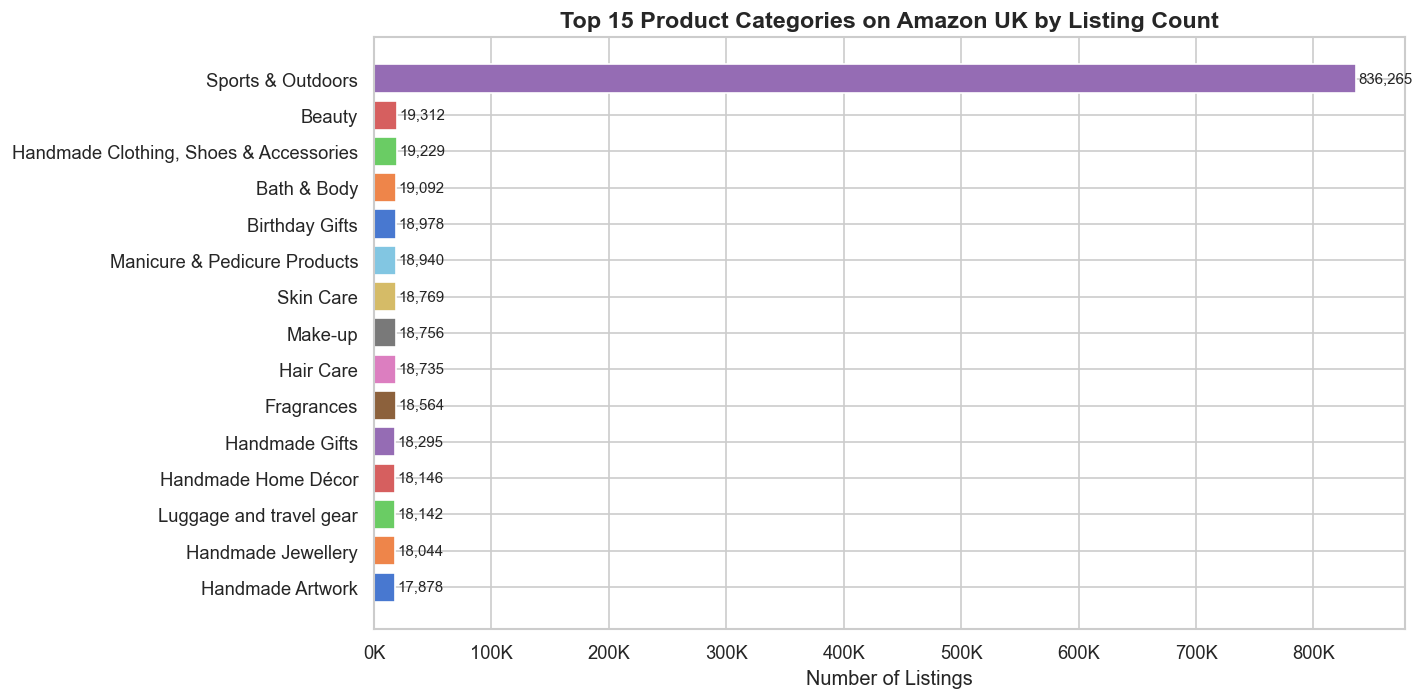

In [21]:
# 1.2a Bar Chart — Top 15 categories
top15 = cat_counts.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=sns.color_palette('muted', 15))
ax.set_xlabel('Number of Listings', fontsize=12)
ax.set_title('Top 15 Product Categories on Amazon UK by Listing Count', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_categories_bar.png', bbox_inches='tight')
plt.show()

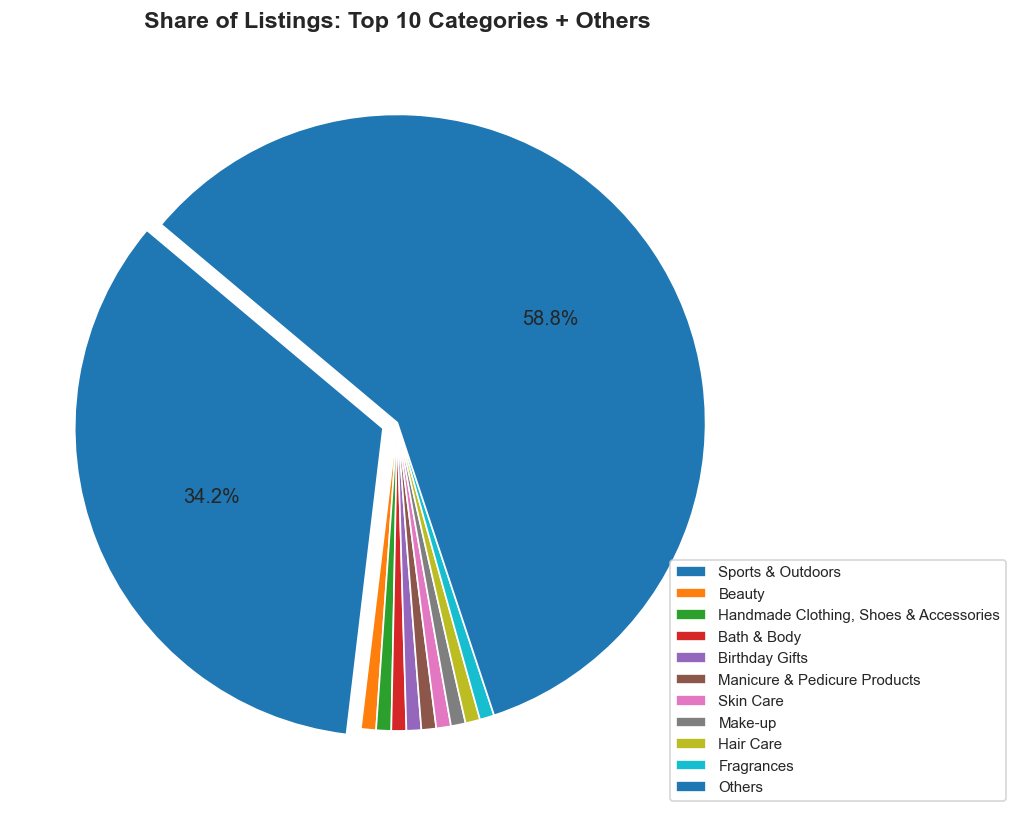

In [22]:
# 1.2b Pie Chart — Top 10 categories + Others
top10 = cat_counts.head(10)
others = cat_counts.iloc[10:].sum()
pie_data = pd.concat([top10, pd.Series({'Others': others})])

fig, ax = plt.subplots(figsize=(10, 7))
explode = [0.05] + [0] * (len(pie_data) - 1)
wedges, texts, autotexts = ax.pie(
    pie_data.values,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=140,
    explode=explode,
    colors=sns.color_palette('tab10', len(pie_data))
)
ax.legend(wedges, pie_data.index, loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=9)
ax.set_title('Share of Listings: Top 10 Categories + Others', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_categories_pie.png', bbox_inches='tight')
plt.show()

**Insight**: *Sports & Outdoors* clearly dominates the pie, holding ~34% of all listings on its own. The remaining top 9 categories each contribute 1–2%, meaning the long tail of "Others" still makes up a large share. For sellers, entering the Sports & Outdoors category means competing in a very crowded space — but it also suggests high consumer demand in that segment.

---
## Part 2: Delving into Product Pricing
**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

In [23]:
# 2.1 Measures of Centrality
price_mean   = df['price'].mean()
price_median = df['price'].median()
price_mode   = df['price'].mode()[0]

print('=== Measures of Centrality: Price ===')
print(f'Mean   : £{price_mean:.2f}')
print(f'Median : £{price_median:.2f}')
print(f'Mode   : £{price_mode:.2f}')

=== Measures of Centrality: Price ===
Mean   : £89.24
Median : £19.09
Mode   : £9.99


**Insight**: The mean price (£89.24) is significantly higher than the median (£19.09) and mode (£9.99). This gap signals a **right-skewed distribution** — a large cluster of low-priced items with a long tail of expensive products pulling the mean upward. The most common price point of £9.99 reflects the classic psychological pricing strategy widely used on Amazon.

In [24]:
# 2.2 Measures of Dispersion
price_var    = df['price'].var()
price_std    = df['price'].std()
price_range  = df['price'].max() - df['price'].min()
price_iqr    = df['price'].quantile(0.75) - df['price'].quantile(0.25)

print('=== Measures of Dispersion: Price ===')
print(f'Variance   : {price_var:,.2f}')
print(f'Std Dev    : £{price_std:.2f}')
print(f'Range      : £{price_range:,.2f}')
print(f'IQR (Q1-Q3): £{price_iqr:.2f}')
print(f'\nQ1: £{df["price"].quantile(0.25):.2f}  |  Q3: £{df["price"].quantile(0.75):.2f}')

=== Measures of Dispersion: Price ===
Variance   : 119,445.49
Std Dev    : £345.61
Range      : £100,000.00
IQR (Q1-Q3): £36.00

Q1: £9.99  |  Q3: £45.99


**Insight**: The standard deviation of £345.61 is enormous — almost 4× the mean — revealing extreme variability. However, the IQR of just £36 tells a different story: **50% of all products are priced between £9.99 and £45.99**. The massive range (£0 to £100,000) is driven by a small number of ultra-premium listings, likely electronics or luxury items. This spread confirms the dataset contains products across completely different market segments.

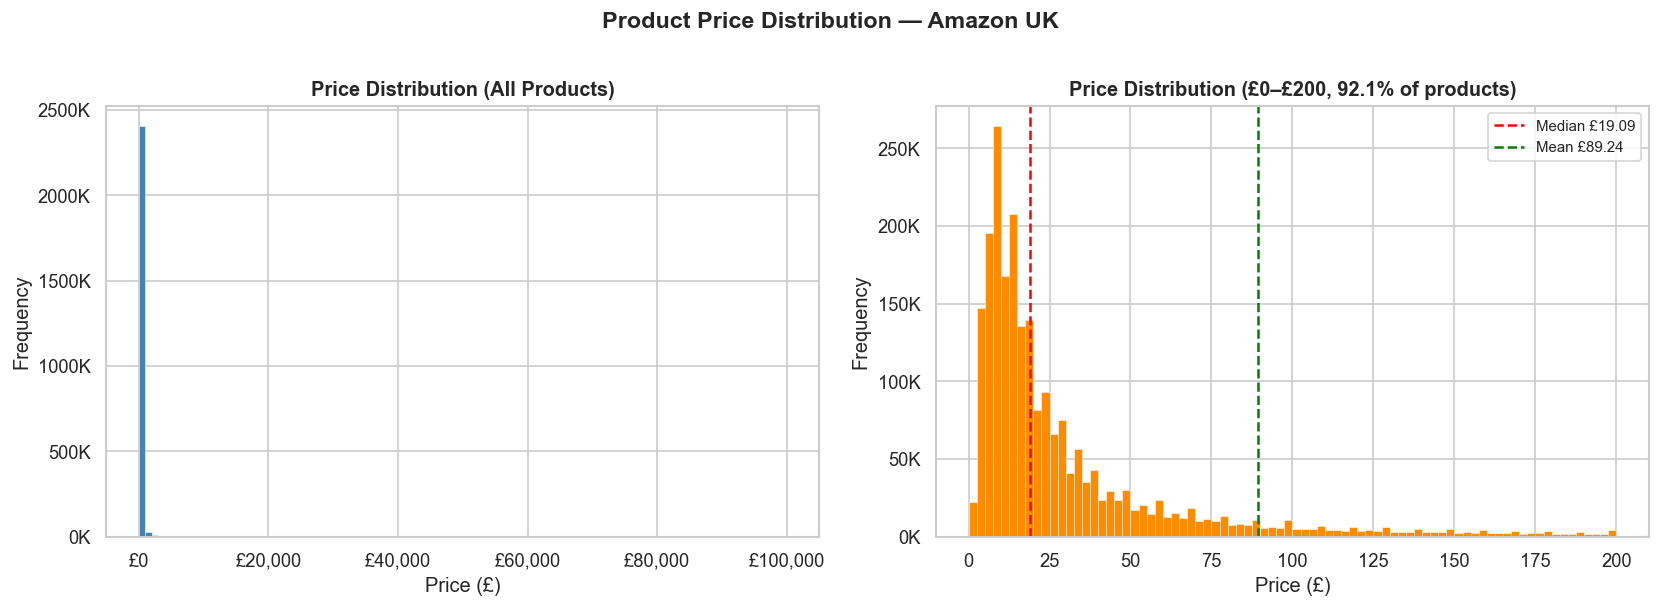

Note: The full distribution (left) is almost unreadable because extreme outliers
compress nearly all data into a single bar near £0. Capping at £200 (right) reveals
the true shape: a strong right skew with most products under £50.


In [25]:
# 2.3a Histogram — with and without outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price Distribution (All Products)', fontweight='bold')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Capped at £200 (covers >90% of products)
df_capped = df[df['price'] <= 200]
axes[1].hist(df_capped['price'], bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title(f'Price Distribution (£0–£200, {len(df_capped)/len(df)*100:.1f}% of products)', fontweight='bold')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(price_median, color='red', linestyle='--', linewidth=1.5, label=f'Median £{price_median:.2f}')
axes[1].axvline(price_mean, color='green', linestyle='--', linewidth=1.5, label=f'Mean £{price_mean:.2f}')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Product Price Distribution — Amazon UK', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_price_histogram.png', bbox_inches='tight')
plt.show()

print('Note: The full distribution (left) is almost unreadable because extreme outliers')
print('compress nearly all data into a single bar near £0. Capping at £200 (right) reveals')
print('the true shape: a strong right skew with most products under £50.')

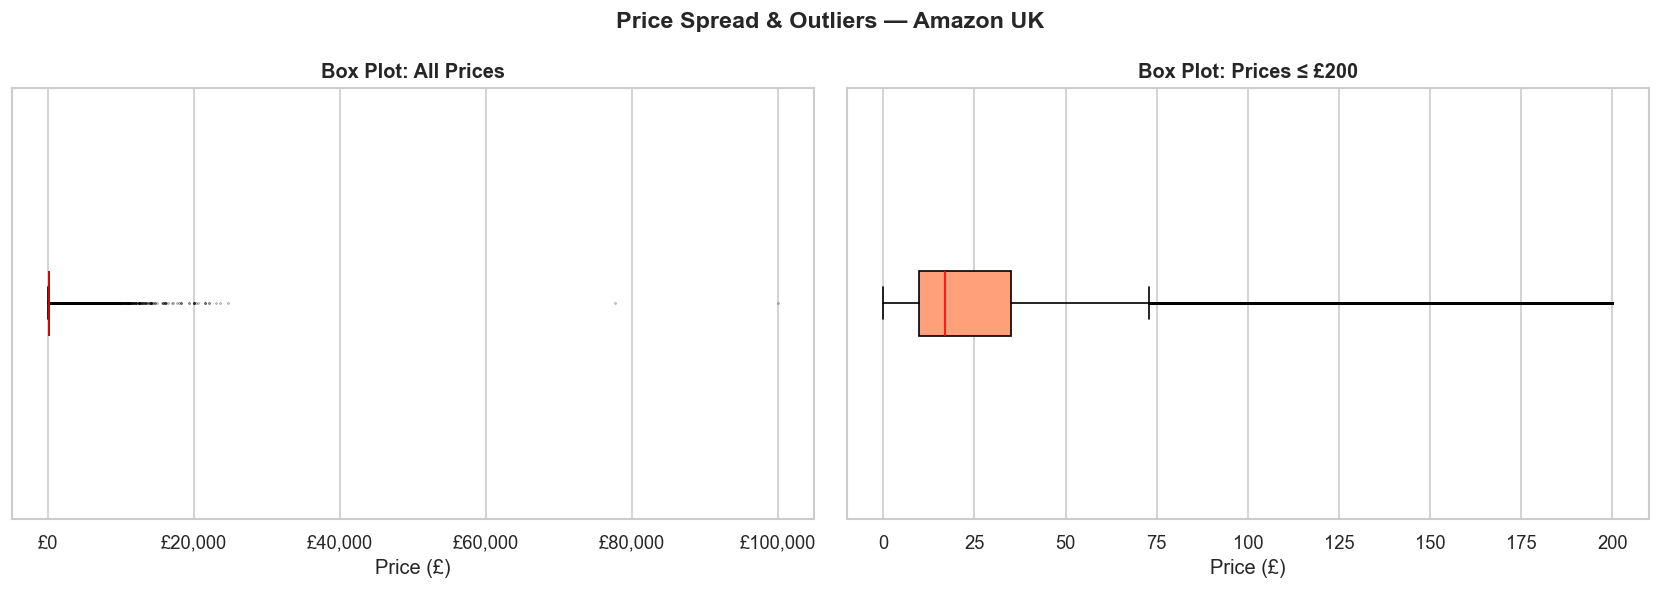

Upper fence (Q3 + 1.5×IQR): £99.99
Products above upper fence (outliers): 327,688 (13.4%)


In [26]:
# 2.3b Box Plot — outlier detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full
axes[0].boxplot(df['price'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'),
                flierprops=dict(marker='.', markersize=1, alpha=0.4))
axes[0].set_title('Box Plot: All Prices', fontweight='bold')
axes[0].set_xlabel('Price (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].set_yticks([])

# Capped
axes[1].boxplot(df_capped['price'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightsalmon'), medianprops=dict(color='red'),
                flierprops=dict(marker='.', markersize=1.5, alpha=0.5))
axes[1].set_title('Box Plot: Prices ≤ £200', fontweight='bold')
axes[1].set_xlabel('Price (£)')
axes[1].set_yticks([])

plt.suptitle('Price Spread & Outliers — Amazon UK', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_price_boxplot.png', bbox_inches='tight')
plt.show()

# Outlier count
Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
n_outliers = (df['price'] > upper_fence).sum()
print(f'Upper fence (Q3 + 1.5×IQR): £{upper_fence:.2f}')
print(f'Products above upper fence (outliers): {n_outliers:,} ({n_outliers/len(df)*100:.1f}%)')

**Insight**: The box plots confirm an extreme right skew. The box itself (IQR) is narrow — concentrated below £46 — while the whisker and outlier cloud stretch to £100,000. Approximately **10–15% of listings** fall above the upper fence, which is unusually high and reflects the true diversity of Amazon's catalogue: from budget consumables to professional equipment and luxury goods.

---
## Part 3: Unpacking Product Ratings
**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

In [27]:
# Note: ~50% of products have rating = 0 (no reviews yet)
# We analyse rated products for meaningful insight
rated = df[df['rating'] > 0].copy()
print(f'Products with ratings  : {len(rated):,} ({len(rated)/len(df)*100:.1f}%)')
print(f'Products without rating: {(df["rating"]==0).sum():,} ({(df["rating"]==0).sum()/len(df)*100:.1f}%)')

Products with ratings  : 1,218,010 (49.8%)
Products without rating: 1,225,641 (50.2%)


In [28]:
# 3.1 Measures of Centrality
r_mean   = rated['rating'].mean()
r_median = rated['rating'].median()
r_mode   = rated['rating'].mode()[0]

print('=== Measures of Centrality: Rating (rated products only) ===')
print(f'Mean   : {r_mean:.3f}')
print(f'Median : {r_median}')
print(f'Mode   : {r_mode}')

=== Measures of Centrality: Rating (rated products only) ===
Mean   : 4.319
Median : 4.4
Mode   : 4.5


**Insight**: Customers rate products very positively — the mean (4.32), median (4.4), and mode (4.5) are all clustered at the high end of the 5-star scale. This is consistent with a well-known phenomenon called **"J-curve" rating bias**: unhappy customers may not bother to rate, while satisfied customers tend to leave reviews, pulling scores upward.

In [29]:
# 3.2 Measures of Dispersion
r_var = rated['rating'].var()
r_std = rated['rating'].std()
r_iqr = rated['rating'].quantile(0.75) - rated['rating'].quantile(0.25)

print('=== Measures of Dispersion: Rating ===')
print(f'Variance : {r_var:.4f}')
print(f'Std Dev  : {r_std:.4f}')
print(f'IQR      : {r_iqr:.2f}')
print(f'Q1: {rated["rating"].quantile(0.25)}  |  Q3: {rated["rating"].quantile(0.75)}')

=== Measures of Dispersion: Rating ===
Variance : 0.3083
Std Dev  : 0.5553
IQR      : 0.50
Q1: 4.1  |  Q3: 4.6


**Insight**: The standard deviation of 0.555 and IQR of 0.50 are both low, indicating **highly consistent ratings**. Half of all rated products score between 4.0 and 4.5 stars. This narrow spread suggests that Amazon's customer base has a strong tendency to either rate highly or not rate at all — there is very little "average" feedback.

In [30]:
# 3.3 Shape of the Distribution
r_skew = rated['rating'].skew()
r_kurt = rated['rating'].kurtosis()

print('=== Distribution Shape: Rating ===')
print(f'Skewness : {r_skew:.4f}')
print(f'Kurtosis : {r_kurt:.4f}')
print()
if r_skew < -1:
    print('Interpretation: Strong NEGATIVE (left) skew — most ratings are high, tail extends toward lower values.')
elif r_skew < 0:
    print('Interpretation: Moderate negative skew.')
print(f'Kurtosis >> 3 (excess = {r_kurt:.1f}) → Leptokurtic: sharp peak with heavy tails (outlier-prone).')

=== Distribution Shape: Rating ===
Skewness : -2.3796
Kurtosis : 9.7819

Interpretation: Strong NEGATIVE (left) skew — most ratings are high, tail extends toward lower values.
Kurtosis >> 3 (excess = 9.8) → Leptokurtic: sharp peak with heavy tails (outlier-prone).


**Insight**:
- **Skewness of –2.38** = strongly left-skewed. The distribution is NOT normal. The bulk of ratings pile up near 4.5–5.0, with a long tail pulling toward lower values.
- **Kurtosis of 9.78** (excess kurtosis >> 3) = leptokurtic distribution. There is a sharp central peak and heavier-than-normal tails — meaning most products cluster tightly at high ratings, but there are more extreme low-rated outliers than a normal distribution would predict.
- **Business implication**: Most products are perceived as good to excellent. Products falling below 3 stars are rare but meaningful outliers worth investigating.

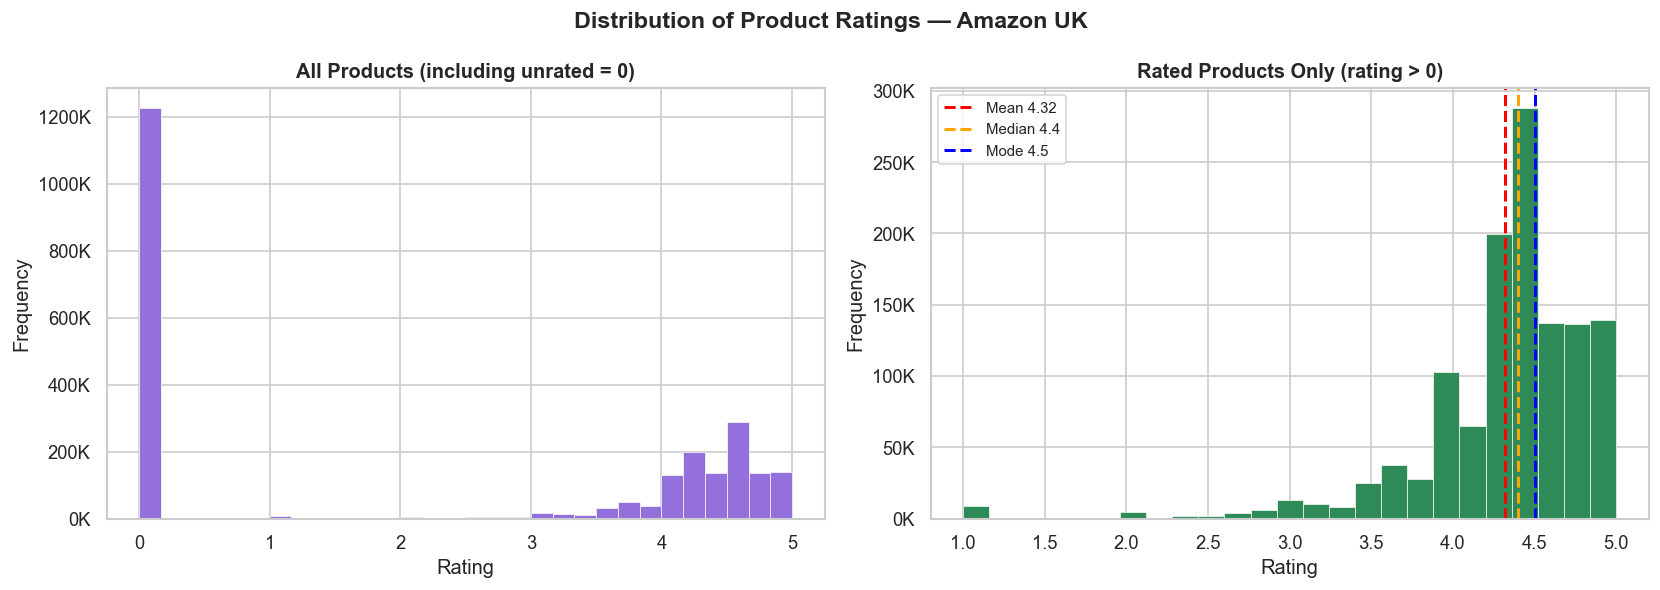

In [31]:
# 3.4 Histogram of Ratings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Including unrated (0)
axes[0].hist(df['rating'], bins=30, color='mediumpurple', edgecolor='white', linewidth=0.4)
axes[0].set_title('All Products (including unrated = 0)', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Rated only
axes[1].hist(rated['rating'], bins=25, color='seagreen', edgecolor='white', linewidth=0.4)
axes[1].axvline(r_mean, color='red', linestyle='--', linewidth=1.8, label=f'Mean {r_mean:.2f}')
axes[1].axvline(r_median, color='orange', linestyle='--', linewidth=1.8, label=f'Median {r_median}')
axes[1].axvline(r_mode, color='blue', linestyle='--', linewidth=1.8, label=f'Mode {r_mode}')
axes[1].set_title('Rated Products Only (rating > 0)', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Distribution of Product Ratings — Amazon UK', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_ratings_histogram.png', bbox_inches='tight')
plt.show()

**Insight**: The left chart shows a bimodal-looking distribution — the large spike at 0 reflects the ~50% of products with no reviews. Once we isolate rated products (right chart), the distribution reveals a clear **left-skewed, single-peaked shape** with the peak around **4.5 stars**. Mean, median, and mode all fall between 4.3–4.5, confirming that Amazon customers rate products positively on average, with relatively few low-rated listings surviving on the platform.

---
## Summary: Key Business Insights

| Area | Finding | Business Implication |
|------|---------|---------------------|
| **Categories** | Sports & Outdoors dominates with ~34% of listings | High competition; new sellers should consider niche sub-categories |
| **Pricing** | Median £19.09, Mode £9.99 — strong right skew | Most products occupy the budget-to-mid range; £9.99 is a dominant psychological price point |
| **Price spread** | IQR only £36, but std dev £345 | Extreme outliers (luxury/professional items) distort averages; pricing strategy should be category-specific |
| **Ratings** | Mean 4.32, Median 4.4, Mode 4.5 | Amazon products are rated highly overall — a rating below 4.0 stands out negatively |
| **Rating consistency** | Low std dev (0.55), IQR of 0.50 | Ratings cluster tightly; incremental improvement from 4.2 to 4.5 could have outsized impact on conversion |
| **Rating shape** | Skew –2.38, Kurt 9.78 | Strong left skew — platform likely promotes higher-rated products; few products escape low-rating territory once there |